# cu_inj Reference simulation 

with 300k particles

In [1]:
from impact import Impact
from distgen import Generator
import os
%config InlineBackend.figure_format = 'retina' # nicer plotting

NAME = 'impact_cu_inj_v0_300k_particles'

GFILE = os.path.expandvars('$LCLS_LATTICE/distgen/models/cu_inj/v0/distgen.yaml')
YFILE = os.path.expandvars('$LCLS_LATTICE/impact/models/cu_inj/v0/ImpactT.yaml')

# Create particles

In [2]:
%%time
G = Generator(GFILE)
G['n_particle'] = 300_000
G.run()
P0 = G.particles

CPU times: user 1.1 s, sys: 73.1 ms, total: 1.18 s
Wall time: 1.21 s


# MPI run 

For this many particles we will prepare an MPI run

In [3]:
I = Impact.from_yaml(YFILE)

# Set initial particles
I.initial_particles = P0

In [4]:
# Change some things
I.header['Nx'] = 64
I.header['Ny'] = 64
I.header['Nz'] = 64

# Run

In [5]:
%%time

## Switches for MPI
I.numprocs = 0 # auto-select maximum

I.run()

[ChristophersMBP:23128] [[60884,0],0] ORTE_ERROR_LOG: Data unpack would read past end of buffer in file /opt/local/var/macports/build/_opt_local_var_macports_sources_rsync.macports.org_macports_release_tarballs_ports_science_openmpi/openmpi-gcc12/work/openmpi-4.1.6/orte/util/show_help.c at line 501


CPU times: user 3.27 s, sys: 418 ms, total: 3.69 s
Wall time: 18min 34s


# Plot Output

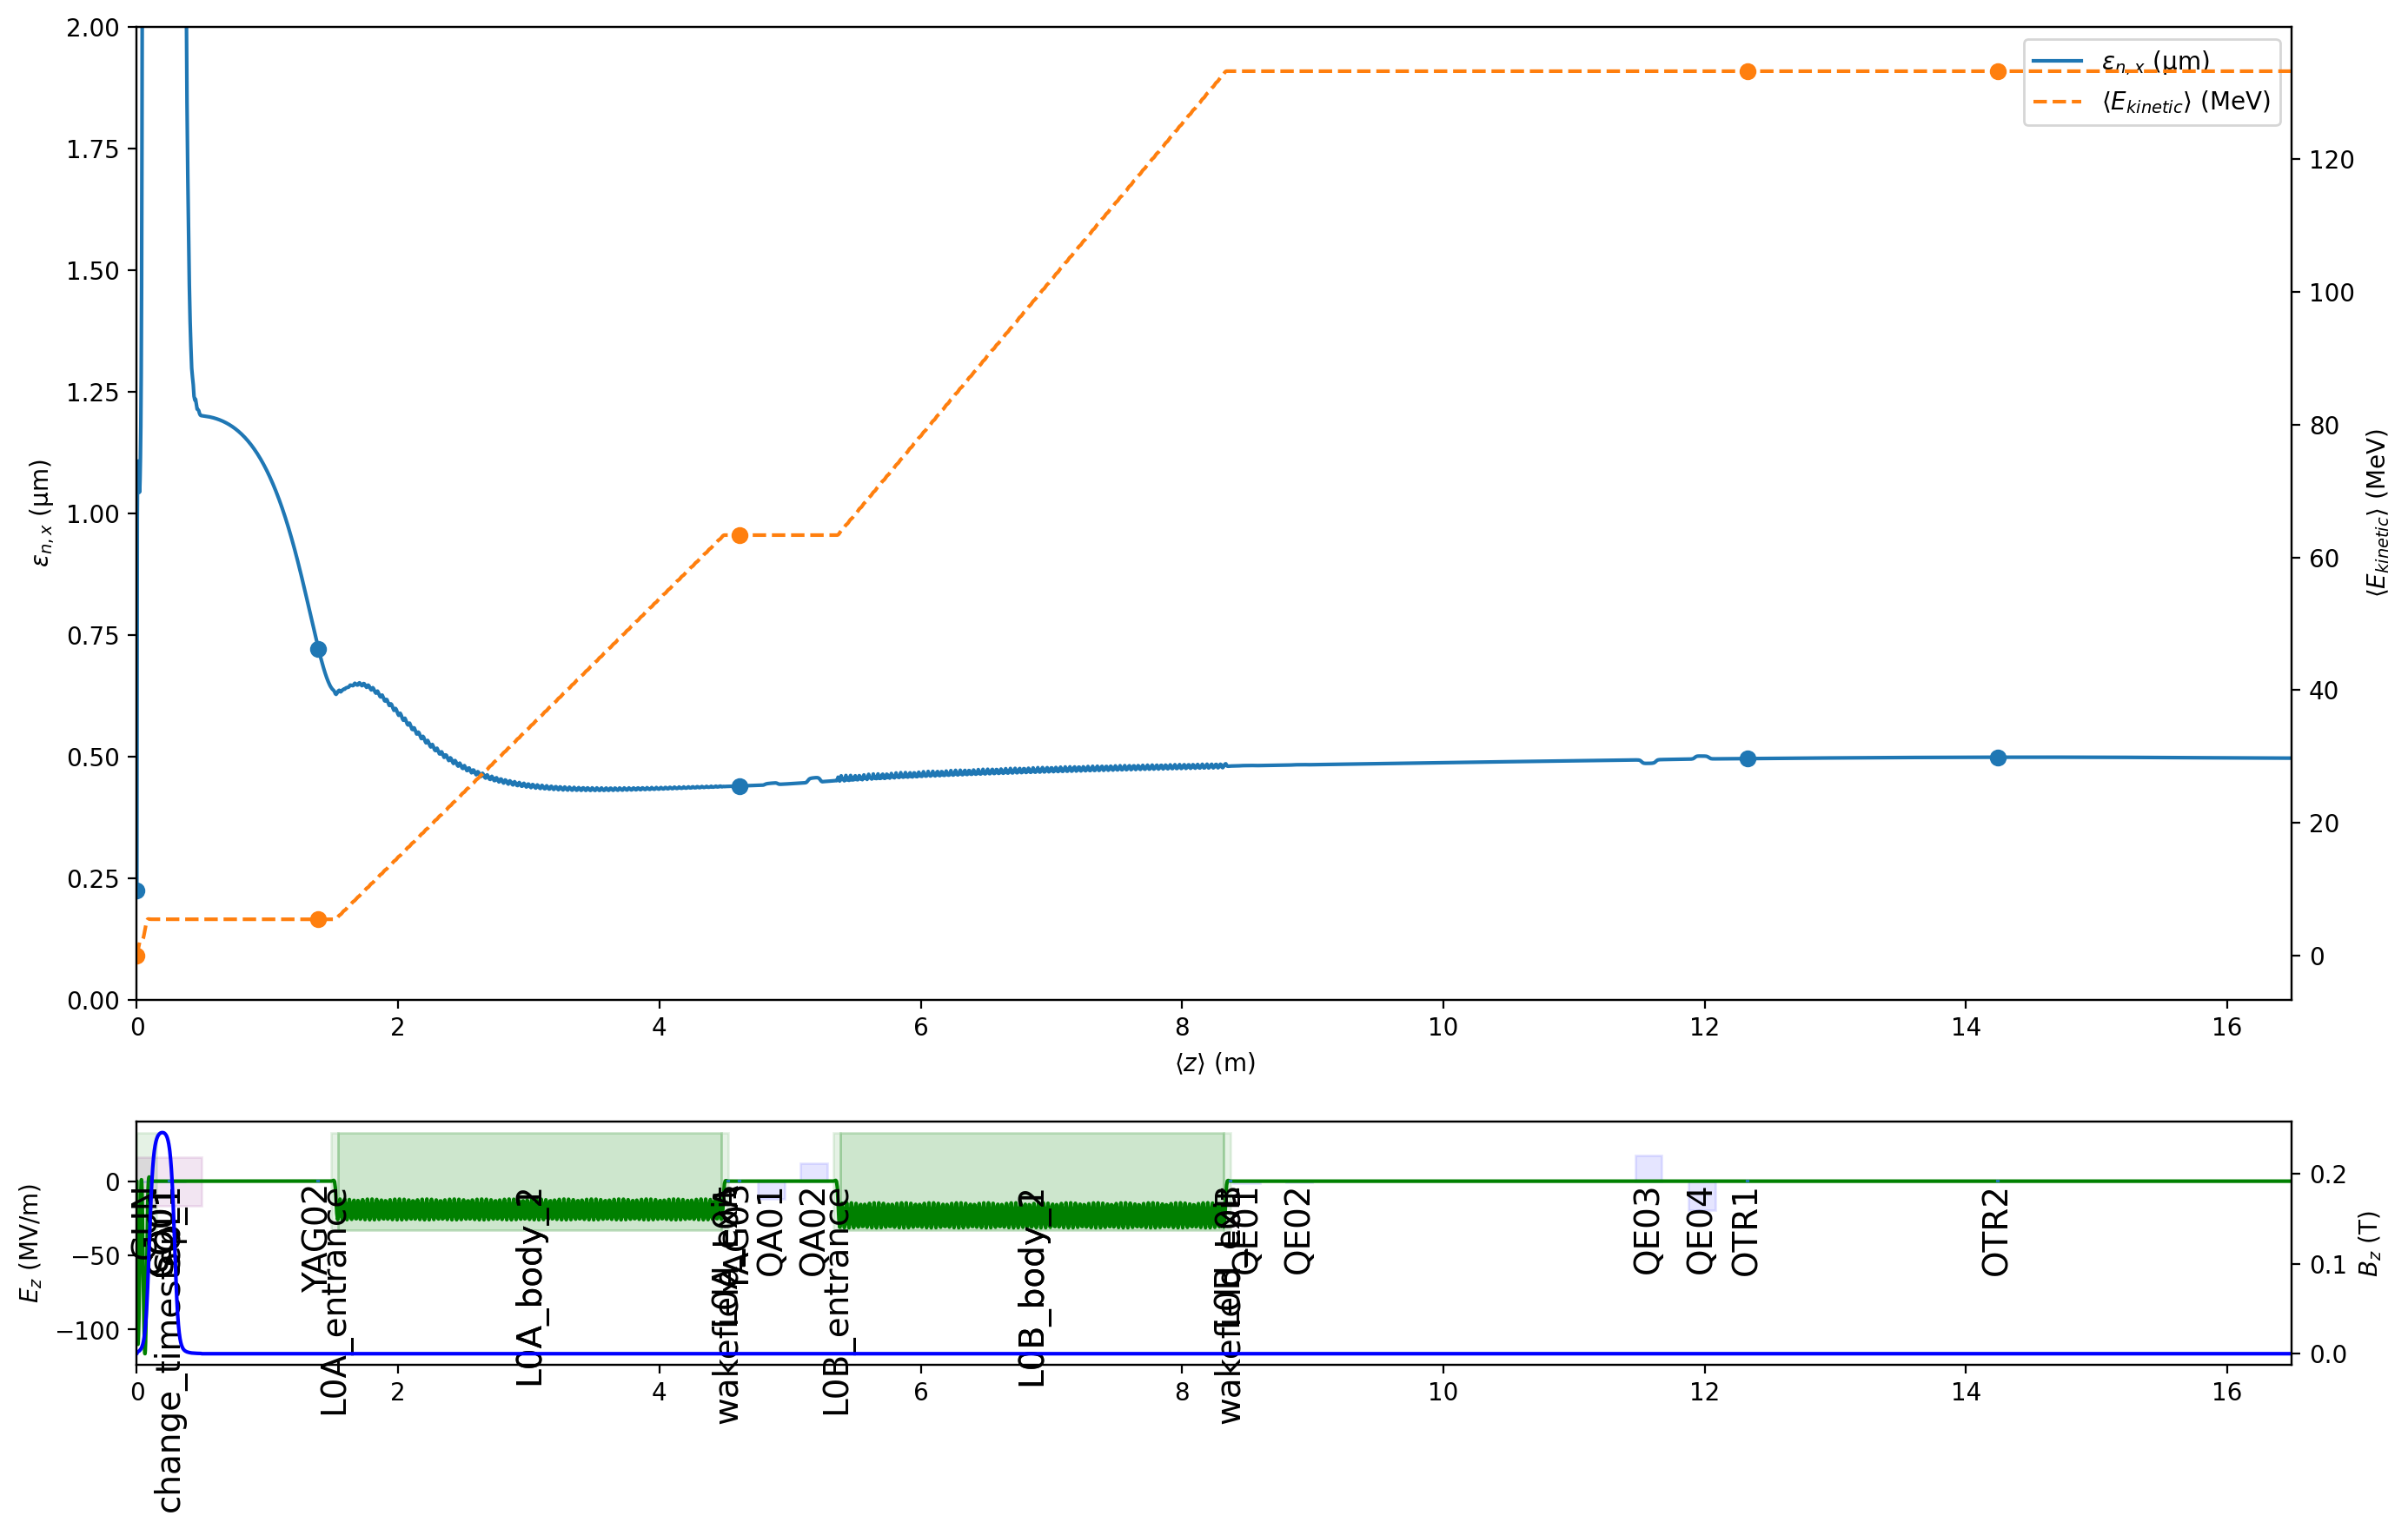

In [6]:
I.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(16,10), include_labels=True)

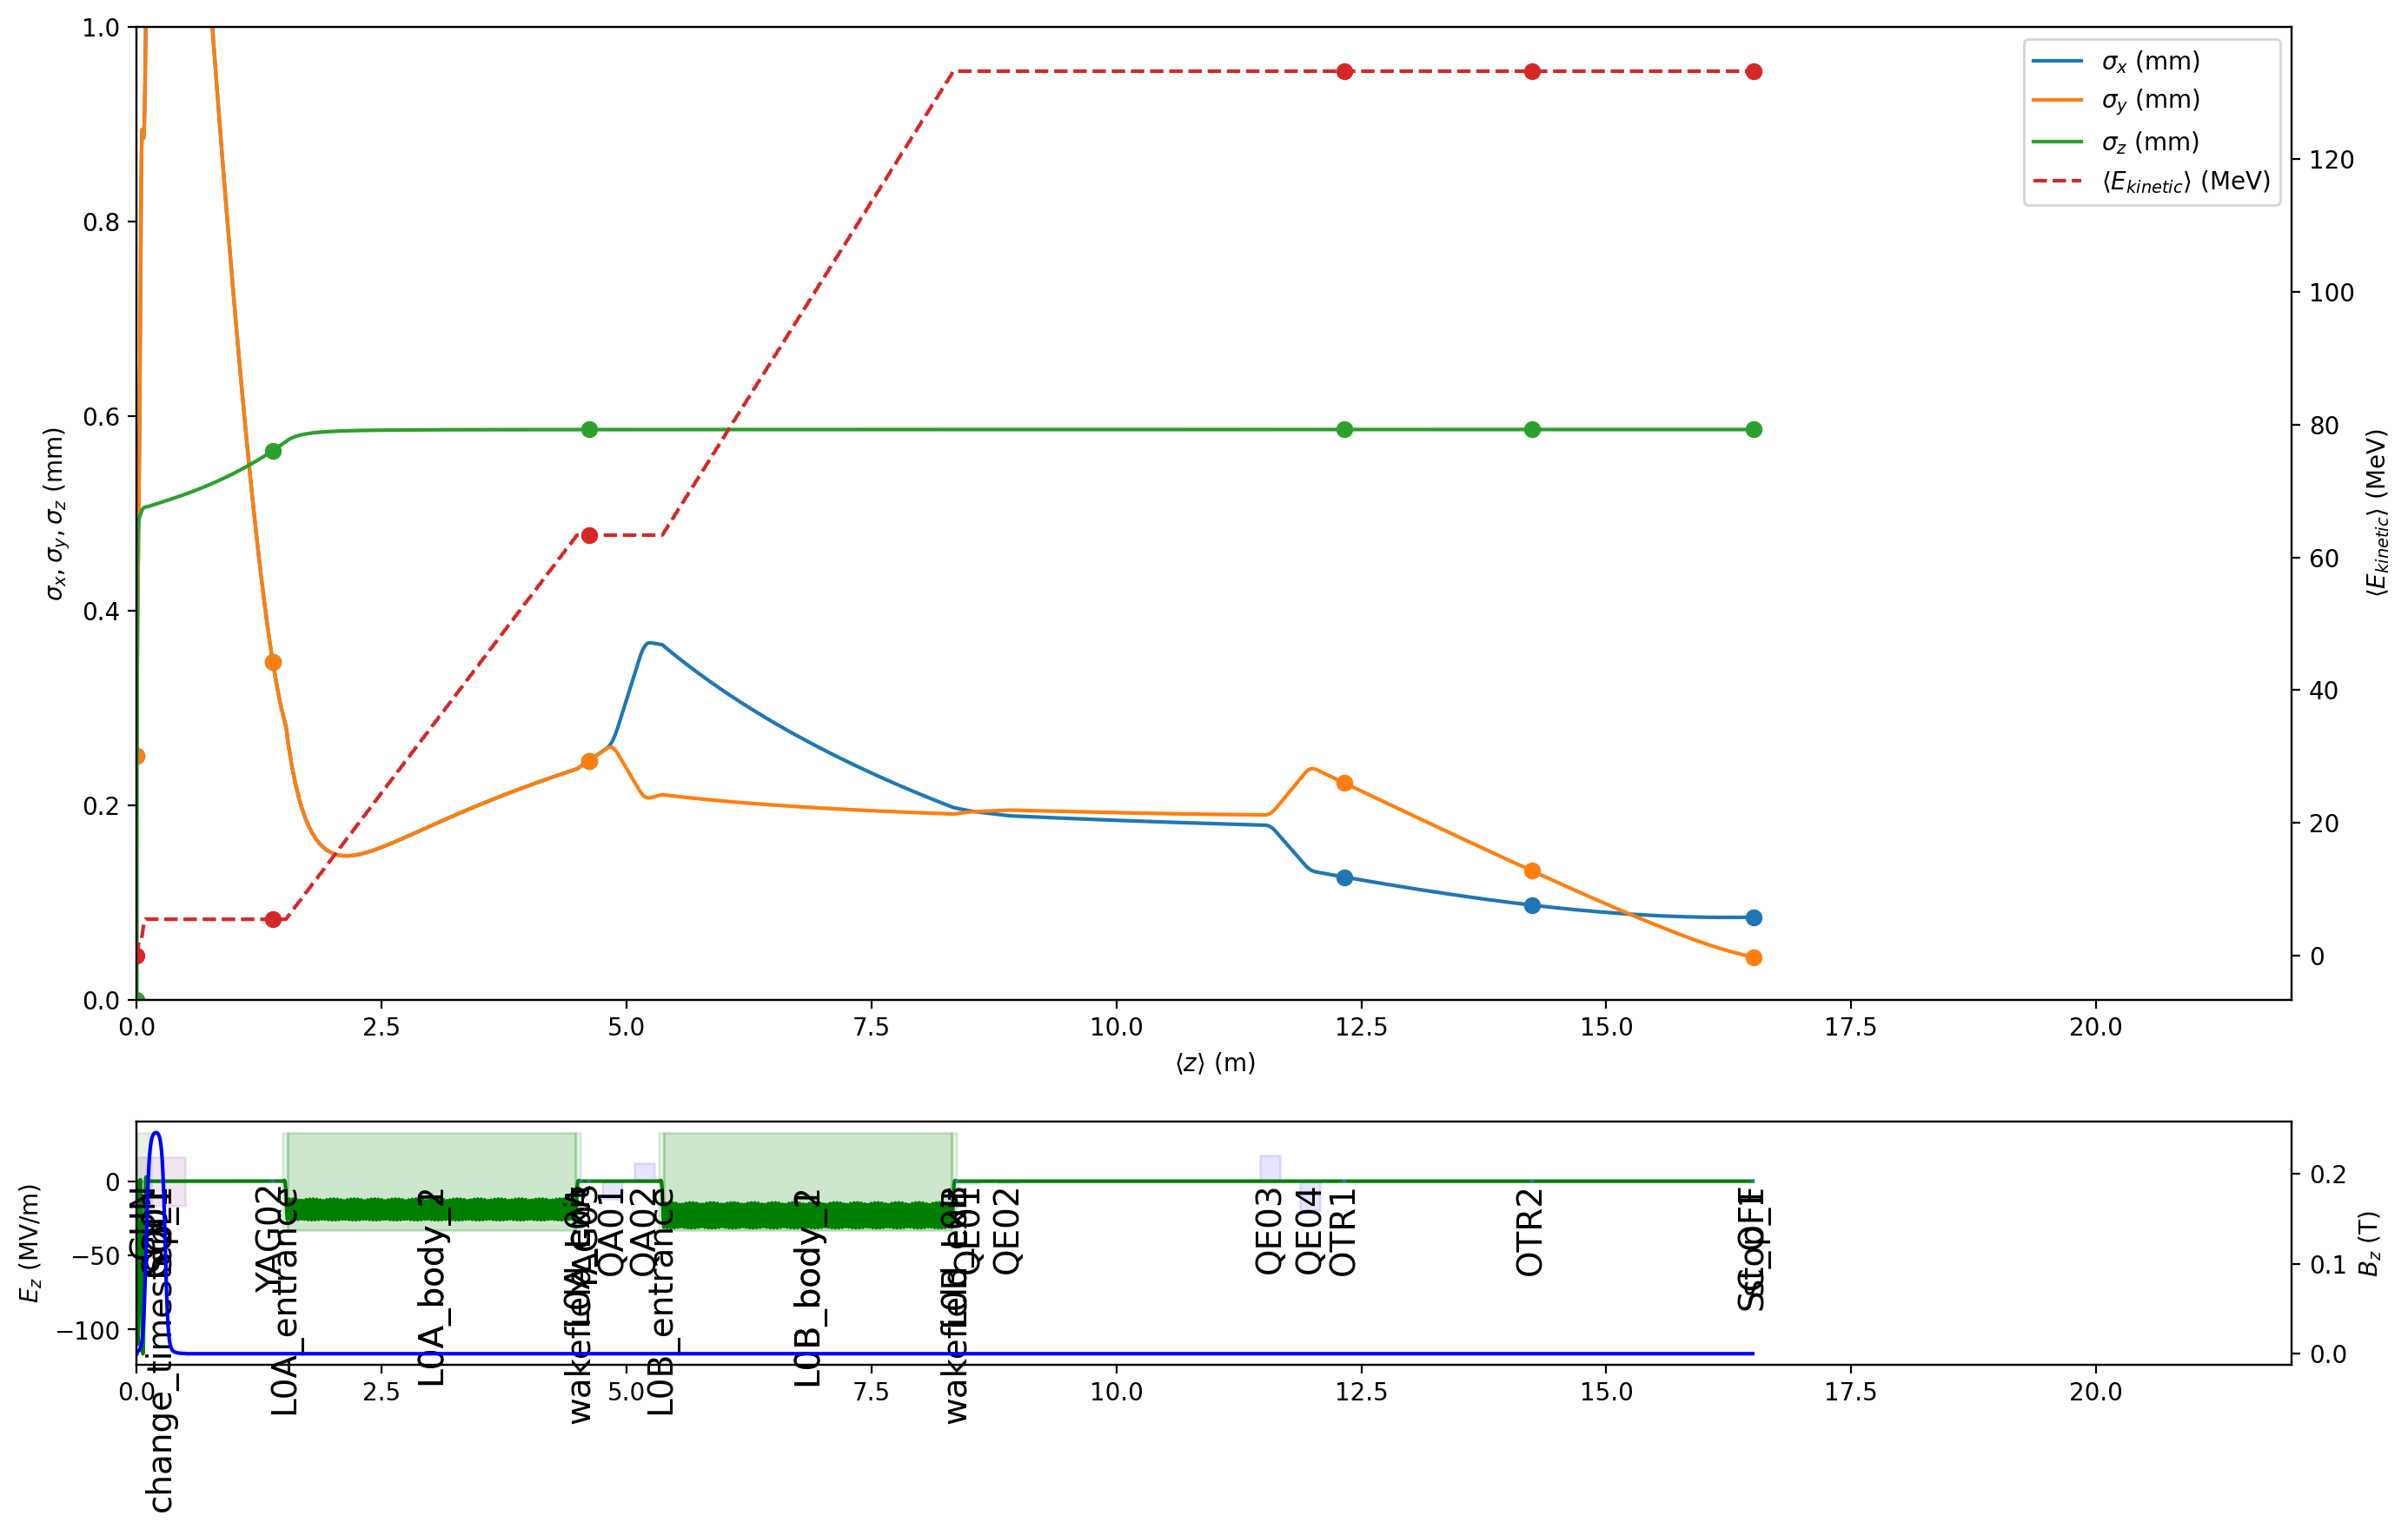

In [7]:
I.plot(['sigma_x', 'sigma_y', 'sigma_z'], y2='mean_kinetic_energy',  ylim=(0, 0.001), xlim=(0, 22), figsize=(16,10), include_labels=True)

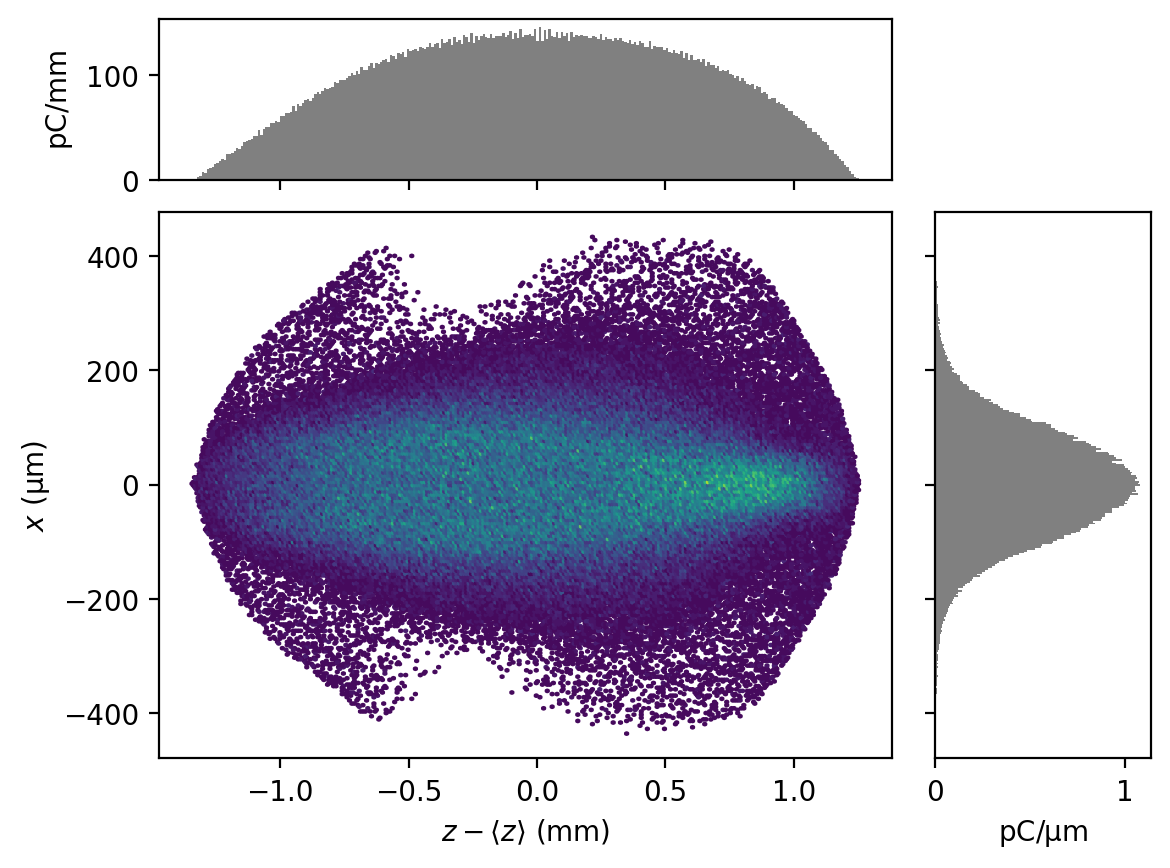

In [8]:
P1 = I.particles['OTR2']

P1.plot('delta_z', 'x')

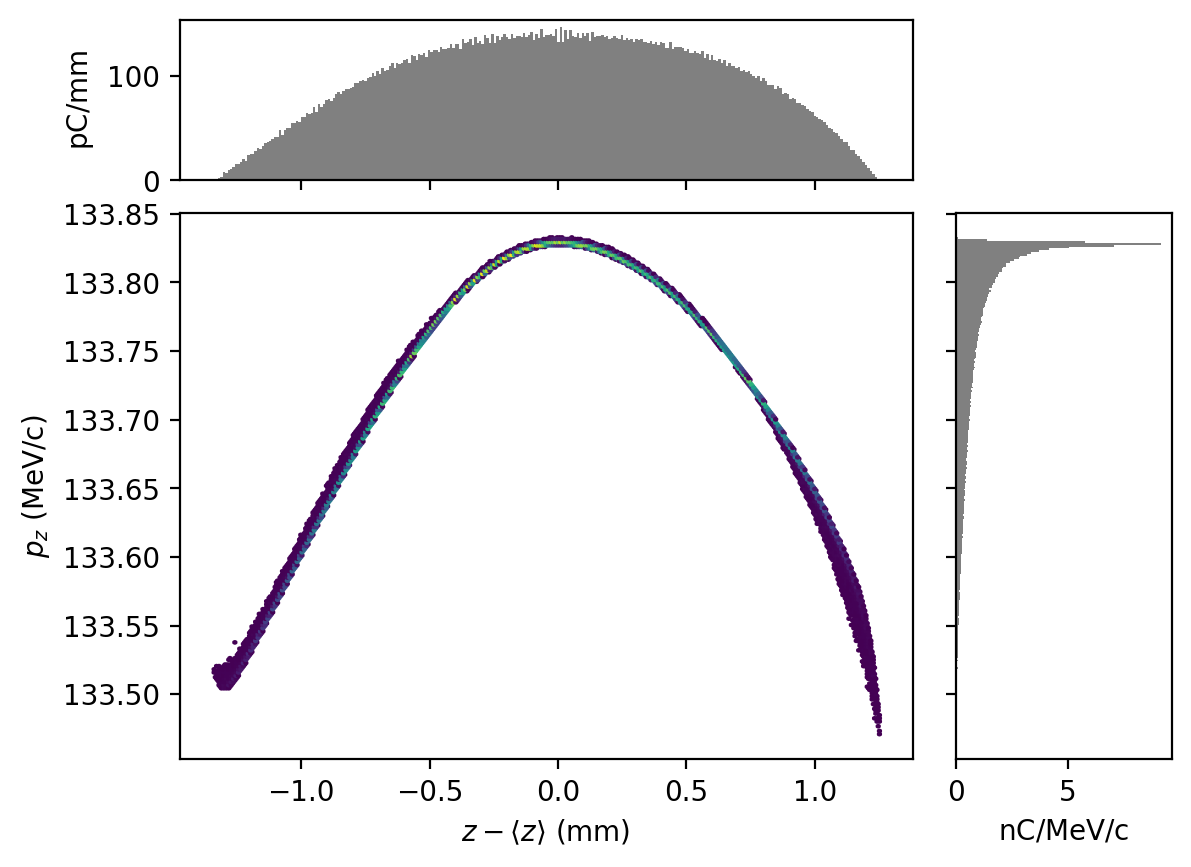

In [9]:
P1.plot('delta_z', 'pz')

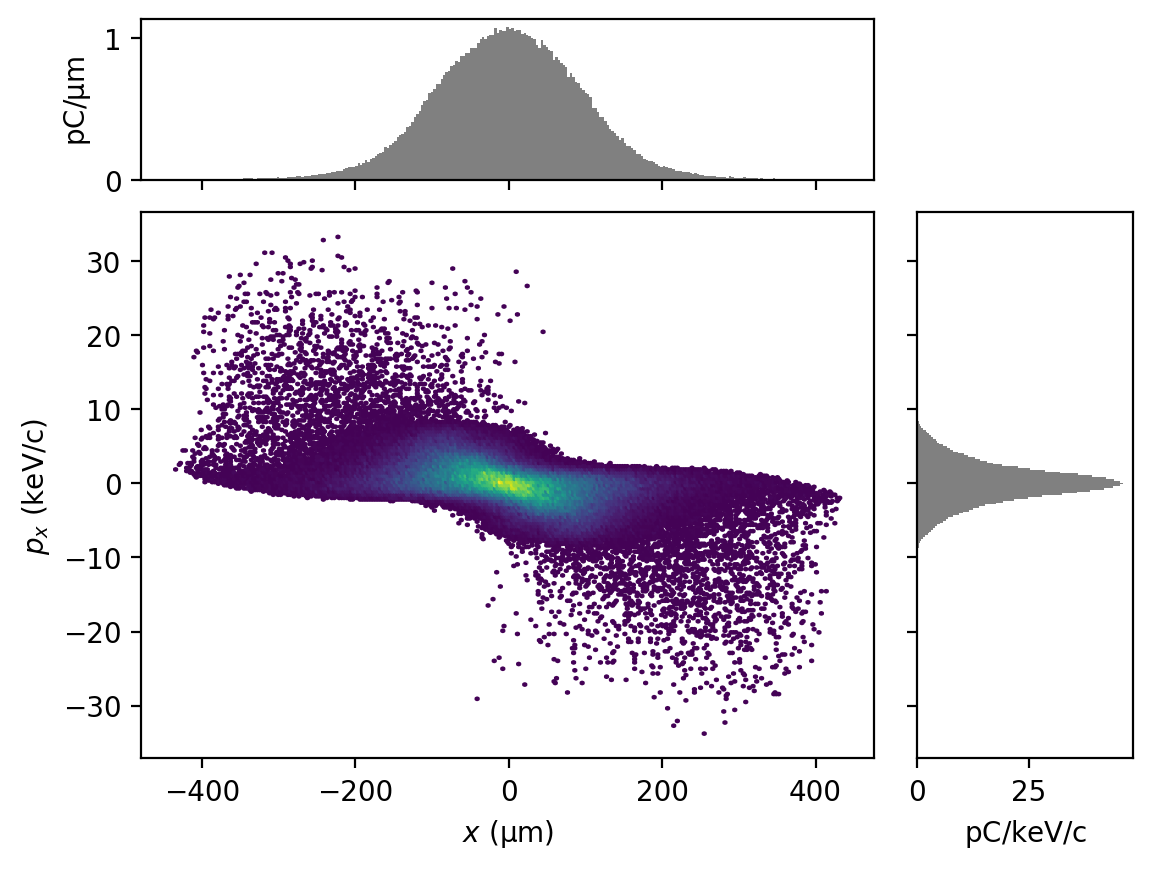

In [10]:
P1.plot('x', 'px')

In [11]:
# 95% Twiss and Emittance
P1.twiss('xy', 0.95)

{'alpha_x': 0.6241814320404333,
 'beta_x': 5.1985148718035585,
 'gamma_x': 0.2673075857955449,
 'emit_x': 1.3614242750413515e-09,
 'eta_x': -6.802065207261809e-05,
 'etap_x': -9.800490398392224e-06,
 'norm_emit_x': 3.5636234244291276e-07,
 'alpha_y': 3.3168322902834486,
 'beta_y': 9.659380154256324,
 'gamma_y': 1.2424582375069526,
 'emit_y': 1.3288713374883893e-09,
 'eta_y': 1.933413393024705e-05,
 'etap_y': -2.6675895679765583e-06,
 'norm_emit_y': 3.4784149860523067e-07}

In [12]:
# Copy basic input to `v0/`
#!cp {I.path}/ImpactT.in {os.path.split(YFILE)[0]}
#!cp {I.path}/partcl.data {os.path.split(YFILE)[0]}

In [13]:
# %%time
# afile = f'/global/cfs/cdirs/m669/www/lume/cu_inj/{NAME}.h5'
# I.archive(afile)

# WWW archive access

In [14]:
# Restore
#!wget https://portal.nersc.gov/cfs/m669/lume/cu_inj/impact_cu_inj_v0_300k_particles.h5

In [15]:
#I2 = Impact.from_archive('impact_cu_inj_v0_300k_particles.h5')
#I2.plot()